# テーマ2 データ可視化とEDA

## 目的
- EDA を「モデル作成前の観察と仮説づくり」として理解する
- 分布、比較、関係、外れ値をグラフで確認する
- グラフを見て、特徴量の違いやクラスごとの傾向を言葉で説明する

## 今日の成果物
- グラフを3つ以上作る
- それぞれのグラフから読み取れることを短く記述する

## 注意
- このNotebookは上から順に実行してください
- `TODO` は小さな変更で進められるようにしてあります


## EDAとは何か

EDA は Exploratory Data Analysis の略で、日本語では探索的データ分析と呼ばれます。目的は、モデルを作る前にデータを観察して仮説を立てることです。

この回では、数値計算よりもグラフを読むことを重視します。

| 観点 | 見るもの | 例 |
| --- | --- | --- |
| 分布 | 値がどの範囲に多いか | ヒストグラム、密度プロット |
| 比較 | グループごとの差 | 箱ひげ図、バイオリンプロット |
| 関係 | 2つの変数のつながり | 散布図、pairplot |
| 外れ値 | 極端な値 | 箱ひげ図、散布図 |

EDA では「グラフを作った」で終わらせず、「そのグラフから何が言えそうか」を書くところまで行います。


### グラフを読むときの型

グラフを見たら、次の3つを分けて書くと考えやすくなります。

1. 事実: 図にそのまま見えていること
2. 解釈: その事実から考えられること
3. 限界: その図だけではまだ言えないこと

例: `petal length (cm)` は品種ごとに分布が分かれて見える。これは分類に役立つ特徴量かもしれない。ただし、図だけでは新しいデータを必ず正しく分類できるとは言えない。


### Step 0: 分析の流れを確認する
このノートブックでは、Iris データを使って可視化の練習をします。分布、グループ差、特徴量どうしの関係、外れ値に注目しながら進めてください。

このあと、ライブラリを読み込み、データの確認、分布の確認、特徴量どうしの関係、外れ値の確認へと進みます。

### Step 0.5: ライブラリを読み込む
EDA の準備として、データ操作と可視化に使うライブラリを読み込みます。以降のセルで同じ前処理を繰り返し使います。

In [1]:
# ===== Step 0: ライブラリ読み込み =====
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris, load_wine

sns.set_theme(style='whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Yu Gothic', 'Arial Unicode MS', 'DejaVu Sans']

### Step 1: データを読み込む
Iris データを DataFrame にして、後で可視化しやすい形に整えます。まずは先頭行を見て、列の構成を確認します。


In [2]:
# ===== Step 1: データ読み込み =====
# TODO: IrisデータをDataFrameとして準備する
# （テーマ1で同じ操作をしています）
iris = load_iris(as_frame=True)
df = iris.frame.copy()
df['species'] = df['target'].map(dict(enumerate(iris.target_names)))
numeric_columns = iris.feature_names

print('行数, 列数 =', df.shape)
print('数値列 =', numeric_columns)
display(df.head())

# ヒント: テーマ1ではここでデータ確認を終え、グラフによる可視化をこのテーマで行います

行数, 列数 = (150, 6)
数値列 = ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


### Step 2: ヒストグラムで分布を見る
まず、1つの特徴量の分布を確認します。値がどの範囲に多いか、山が1つか複数か、極端な値がありそうかを見ます。


### Step 1.5: グラフ描画の基礎

テーマ1ではデータの数値確認まで行いました。ここでは、matplotlib と seaborn を使ってデータをグラフで可視化します。

| ライブラリ | 役割 |
| --- | --- |
| `matplotlib` | グラフ描画の基本ライブラリ |
| `seaborn` | matplotlib を便利に使うための高レベルインターフェース |

Python でグラフを描く基本的な流れ:

1. `plt.figure()` で図のサイズを決める（省略可）
2. 描画関数（`sns.histplot`, `plt.scatter` など）を呼ぶ
3. タイトルや軸ラベルをつける
4. `plt.show()` で表示する

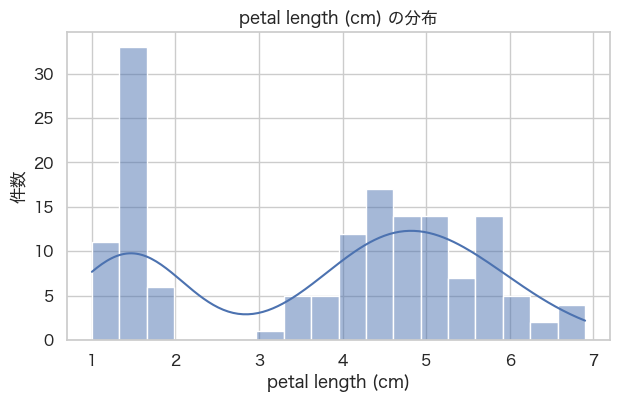

In [3]:
# ===== Step 2: ヒストグラム =====
# TODO: feature を別の列に変えて、分布の違いを確認する
feature = 'petal length (cm)'

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x=feature, bins=18, kde=True)
plt.title(f'{feature} の分布')
plt.xlabel(feature)
plt.ylabel('件数')
plt.show()


#### 解説: ヒストグラムの読み方

ヒストグラムでは、横軸が値、縦軸が件数です。

見るポイント:

- どの範囲にデータが多いか
- 山が1つか、複数あるか
- 左右どちらかに偏っているか
- 他から離れた値があるか

山が複数ある場合、グループごとに分布が違う可能性があります。


### Step 3: 品種ごとに分布を比較する
同じ特徴量でも、品種ごとに分けると見え方が変わります。分類に役立ちそうな特徴量は、品種ごとの分布が分かれて見えることがあります。


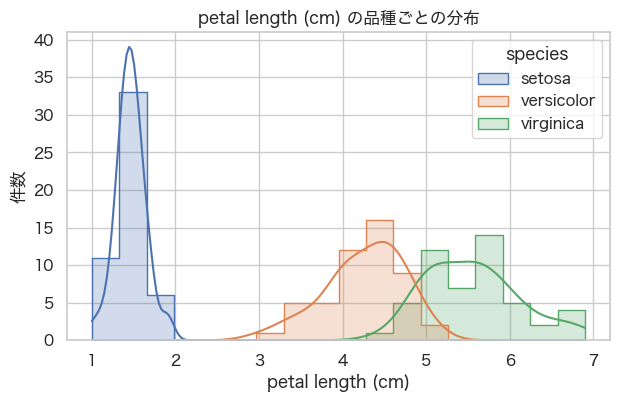

In [4]:
# ===== Step 3: 品種ごとのヒストグラム =====
# TODO: feature を変えて、品種ごとの差が見えやすい列を探す
feature = 'petal length (cm)'

plt.figure(figsize=(7, 4))
sns.histplot(data=df, x=feature, hue='species', bins=18, kde=True, element='step')
plt.title(f'{feature} の品種ごとの分布')
plt.xlabel(feature)
plt.ylabel('件数')
plt.show()


### Step 4: 箱ひげ図でばらつきを見る
品種ごとの分布の違いを箱ひげ図で確認します。中央値やばらつきの差から、分類に効きそうな特徴量を探します。


#### 解説: 箱ひげ図の読み方

箱ひげ図は、値のばらつきを短くまとめる図です。

- 箱の中央線: 中央値
- 箱の下端と上端: 第1四分位数と第3四分位数
- ひげ: 多くのデータが入る範囲
- 点: 外れ値として表示されることがある値

グループごとの箱の位置が大きく違う場合、その特徴量はグループの違いを説明する手がかりになるかもしれません。


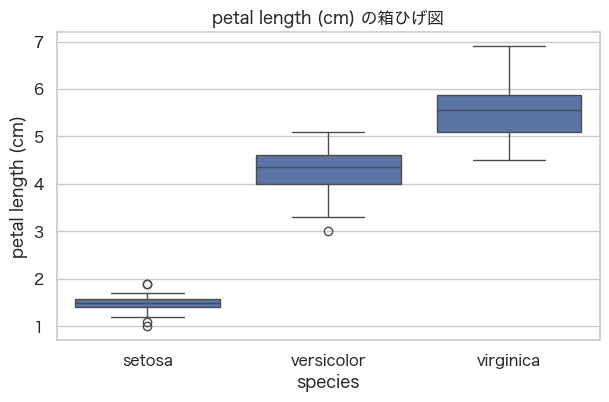

In [5]:
# ===== Step 4: 箱ひげ図 =====
# TODO: どの特徴量が品種ごとに分かれやすいか観察する
target_feature = 'petal length (cm)'  # TODO: 別の列にも変更して試す

plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x='species', y=target_feature)
plt.title(f'{target_feature} の箱ひげ図')
plt.show()


### Step 5: バイオリンプロットで分布の形を見る
バイオリンプロットは、箱ひげ図に分布の形を足したような図です。同じ中央値でも、分布の広がりや山の形が違うことがあります。


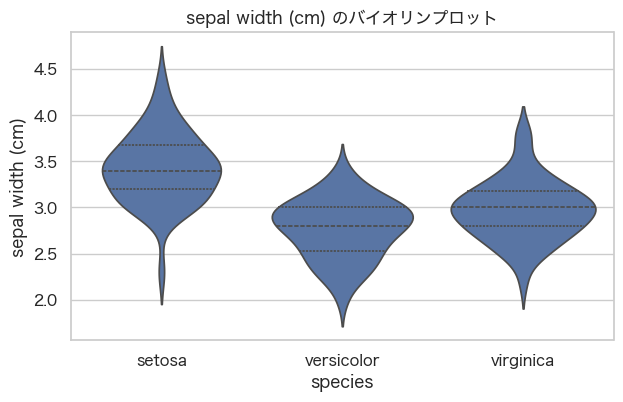

In [6]:
# ===== Step 5: バイオリンプロット =====
# TODO: target_feature を変えて比較する
target_feature = 'sepal width (cm)'

plt.figure(figsize=(7, 4))
sns.violinplot(data=df, x='species', y=target_feature, inner='quartile')
plt.title(f'{target_feature} のバイオリンプロット')
plt.show()


### Step 6: 散布図で2つの特徴量の関係を見る
散布図では、2つの特徴量を同時に見ます。点の並び方と、品種ごとの色の分かれ方に注目してください。


#### 解説: 散布図で関係を見る

散布図では、点の並び方に注目します。

- 右上がり: 一方が大きいほど、もう一方も大きい傾向
- 右下がり: 一方が大きいほど、もう一方は小さい傾向
- ばらばら: 明確な関係が見えにくい
- 色で分かれる: グループを区別する手がかりになる可能性

ここでは相関係数の計算ではなく、見た目からどのような傾向があるかを説明します。


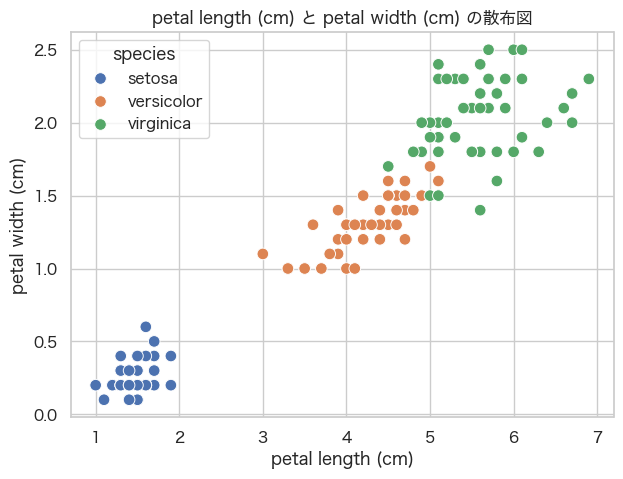

In [7]:
# ===== Step 6: 散布図 =====
# TODO: x_feature と y_feature を変えて、品種が分かれやすい組み合わせを探す
x_feature = 'petal length (cm)'
y_feature = 'petal width (cm)'

plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x=x_feature, y=y_feature, hue='species', s=70)
plt.title(f'{x_feature} と {y_feature} の散布図')
plt.show()


### Step 6.5: 相関ヒートマップで全体の関係を見る
散布図は2変数ずつ確認する方法ですが、相関ヒートマップを使うと数値列どうしの関係をまとめて確認できます。強い正の相関、負の相関、あまり関係がなさそうな組み合わせを探してください。

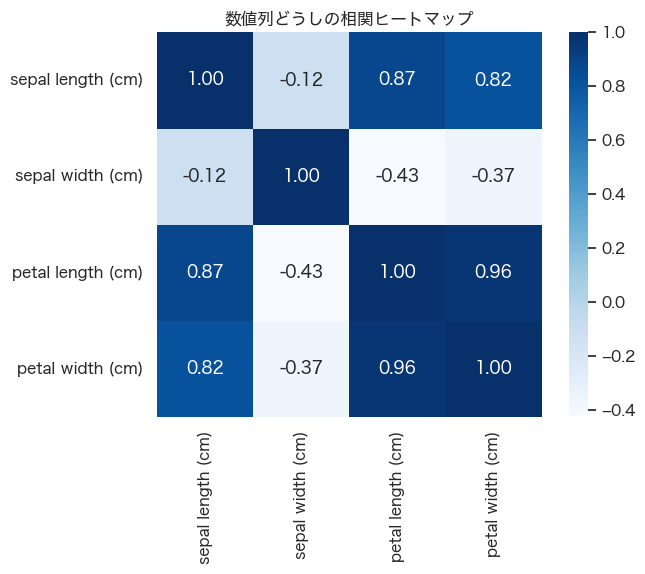

In [8]:
# ===== Step 6.5: 相関ヒートマップ =====
# TODO: 色の濃い組み合わせを見つけて、強い関係がありそうな列を1つ選ぶ
corr_matrix = df[numeric_columns].corr(numeric_only=True)

plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt='.2f', square=True)
plt.title('数値列どうしの相関ヒートマップ')
plt.show()

### Step 6.8: 外れ値を数値で確認する
箱ひげ図では外れ値の候補を目で確認できます。ここでは IQR を使って、どの特徴量に外れ値候補があるかを数でも見てみます。

In [9]:
# ===== Step 6.8: IQRで外れ値候補を確認 =====
# TODO: feature_to_check を変えて、外れ値候補の件数を確認する
feature_to_check = 'sepal width (cm)'

q1 = df[feature_to_check].quantile(0.25)
q3 = df[feature_to_check].quantile(0.75)
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df[feature_to_check] < lower_bound) | (df[feature_to_check] > upper_bound)]

print('確認する列 =', feature_to_check)
print('下限 =', round(lower_bound, 2))
print('上限 =', round(upper_bound, 2))
print('外れ値候補の件数 =', len(outliers))
display(outliers[[feature_to_check, 'species']].head())

確認する列 = sepal width (cm)
下限 = 2.05
上限 = 4.05
外れ値候補の件数 = 4


,sepal width (cm),species
15,4.4,setosa
32,4.1,setosa
33,4.2,setosa
60,2.0,versicolor


### Step 7: pairplot で特徴量どうしの関係をまとめて見る
pairplot を使うと、複数の散布図と分布をまとめて確認できます。全体をざっと見て、品種の違いが出やすい特徴量の組み合わせを探します。


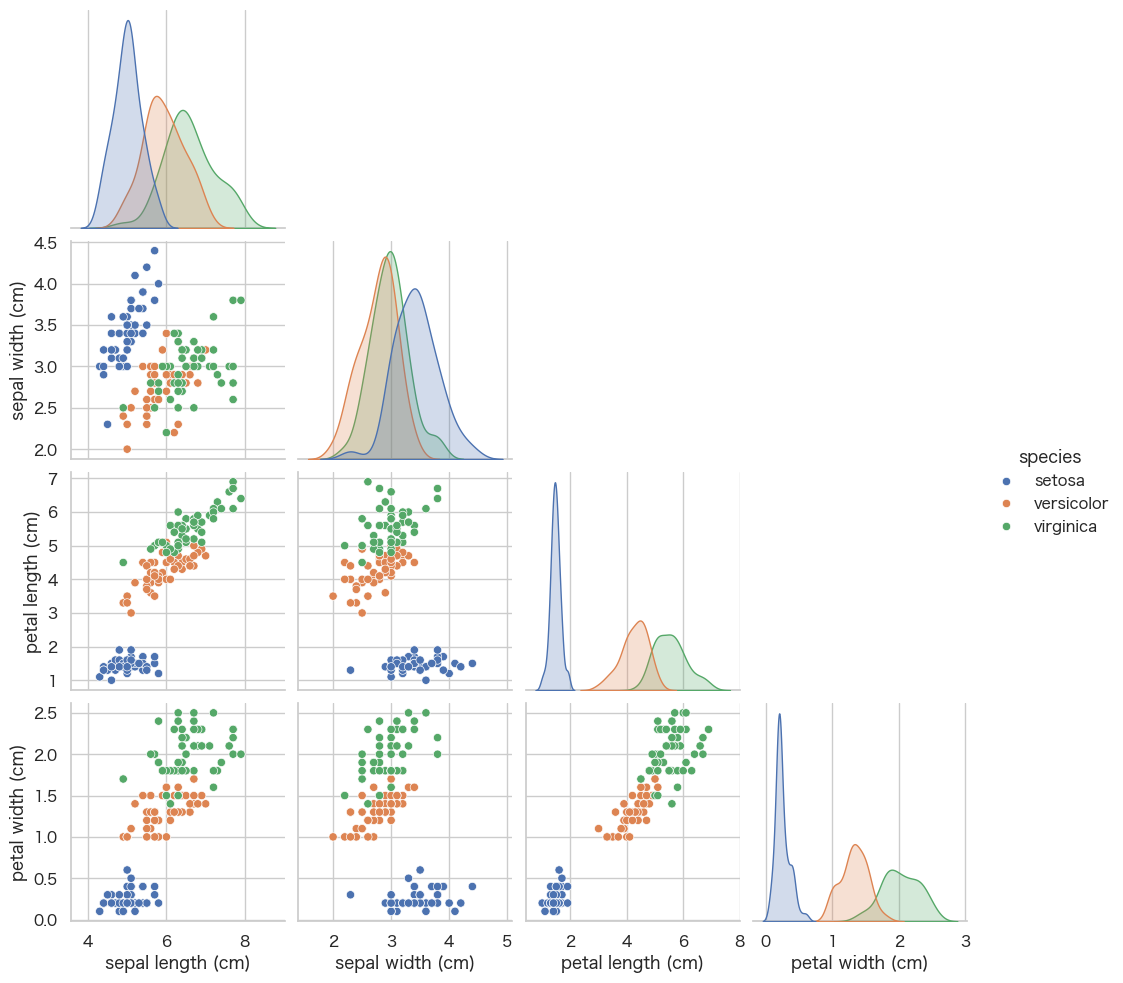

In [10]:
# ===== Step 7: pairplot =====
# TODO: hue に使う列を確認する
pairplot_columns = iris.feature_names + ['species']
sns.pairplot(df[pairplot_columns], hue='species', corner=True)
plt.show()


## 課題
次の問いに短く答えてください。

1. ヒストグラムから、どの特徴量の分布が品種ごとに分かれて見えましたか。
2. 箱ひげ図またはバイオリンプロットから、品種ごとの差が大きい特徴量はどれでしたか。
3. 散布図で、品種が分かれて見えやすい特徴量の組み合わせはどれでしたか。
4. 作成したグラフを3つ選び、それぞれから読み取れることを1文ずつ書いてください。


## 回答欄

1. ヒストグラムから分かれやすいと感じた特徴量:

2. 箱ひげ図またはバイオリンプロットから差が大きいと感じた特徴量:

3. 散布図で分かれやすいと感じた特徴量の組み合わせ:

4. グラフから読み取れたこと:
- 
- 
- 

## 発展演習: Iris 以外のデータで EDA する

ここからは `Wine` データセットを使って、Iris と同じ流れで EDA を行います。

Iris より特徴量の数が多いので、全部を細かく見るよりも、次の観点で 2〜3 個の特徴量を選んで観察してください。

- 分布がクラスごとに違って見えるか
- 箱ひげ図やバイオリンプロットで差が出るか
- 散布図でクラスが分かれて見えるか
- 外れ値候補がありそうか

In [11]:
# ===== 発展演習: Wine データの準備 =====
wine = load_wine(as_frame=True)
exercise_df = wine.frame.copy()
exercise_df['class_name'] = exercise_df['target'].map(dict(enumerate(wine.target_names)))
exercise_numeric_columns = wine.feature_names

print('行数, 列数 =', exercise_df.shape)
print('クラス =', list(wine.target_names))
print('数値列の例 =', exercise_numeric_columns[:5])
display(exercise_df.head())

行数, 列数 = (178, 15)
クラス = [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
数値列の例 = ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium']


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


### 発展課題

1. `exercise_numeric_columns` から 1 つ選び、ヒストグラムを作ってクラスごとの分布の違いを確認してください。
2. 別の特徴量を 1 つ選び、箱ひげ図またはバイオリンプロットでクラス差を確認してください。
3. 2 つの特徴量を選び、散布図でクラスが分かれて見えるかを確認してください。
4. IQR を使って外れ値候補を調べ、どの列に注目したかを書いてください。
5. Iris と比べて、どちらのデータセットのほうがクラス差を読み取りやすかったかを 1〜2 文で書いてください。

必要であれば、これまでの `df` を `exercise_df` に、`species` を `class_name` に読み替えてコードを再利用してかまいません。

## 演習課題

以下の演習をノートブック上で実行し、結果を確認してください。

### 演習1: ヒストグラムと箱ひげ図 (簡単)

1. Irisデータの `petal width (cm)` のヒストグラムを作成してください。
2. 同じ特徴量について、品種ごとに色分けした箱ひげ図を作成してください。
3. この特徴量は品種を区別するのに有効そうですか。理由を1文で書いてください。

```python
# ここにコードを書いてください
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ヒストグラム
df['petal width (cm)'].hist(ax=axes[0], bins=20)
axes[0].set_title('Petal Width Histogram')

# 箱ひげ図（品種ごと）
sns.boxplot(x='species', y='petal width (cm)', data=df, ax=axes[1])
axes[1].set_title('Petal Width by Species')

plt.tight_layout()
plt.show()
```

### 演習2: 散布図で関係を確認 (簡単)

1. `sepal length (cm)` と `sepal width (cm)` の散布図を作成し、品種ごとに色分けしてください。
2. この2つの特徴量だけで品種を区別するのは容易そうですか。理由を書いてください。

```python
# ここにコードを書いてください
plt.figure(figsize=(8, 6))
sns.scatterplot(x='sepal length (cm)', y='sepal width (cm)', hue='species', data=df)
plt.title('Sepal Length vs Sepal Width')
plt.show()
```

### 演習3: 相関行列の読み取り (簡単)

1. Irisデータの数値列について相関行列を計算し、ヒートマップで表示してください。
2. `target`（品種）と最も強い相関がある特徴量はどれですか。

```python
# ここにコードを書いてください
corr = df[numeric_columns + ['target']].corr(numeric_only=True)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()
```

---

## レポート課題

以下のレポートを提出してください（A4 1ページ程度、またはノートブックのセルに記述）。

### レポート項目

1. **EDAの目的** (200字程度)
   - なぜモデルを作る前にデータを観察するのでしょうか。EDAの重要性を自分の言葉で説明してください。

2. **可視化結果の解釈** (300字程度)
   - 演習で作成したグラフのうち、最も印象に残ったものを1つ選び、そこから読み取れることを説明してください。「〜分布は右に偏っている」「〜特徴量はクラス間で明確に分かれている」など、具体的な観察を記述してください。

3. **仮説立案** (200字程度)
   - 可視化の結果から、「どの特徴量が分類に役立ちそうか」という仮説を立ててください。その根拠として、どのグラフや数値を挙げますか。

